In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler,StandardScaler
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

In [3]:

data=pd.read_excel("Data\data_combined_synth_Ra_density_86.xlsx")
data=data.dropna()
data=data[['p','v','h','t','Ra','density']]


In [4]:
data.describe()

,p,v,h,t,Ra,density
count,1193.000000,1193.000000,1193.000000,1193.000000,1193.000000,1193.000000
mean,155.045880,711.625626,86.551116,28.989676,8.865739,96.659837
std,47.407902,245.252140,17.729337,6.708072,3.730111,3.722195
min,60.000000,250.000000,50.000000,20.000000,2.101716,79.530000
25%,149.079628,497.416404,76.788037,24.765379,6.060000,95.253134
50%,150.015357,693.720805,80.051627,29.994704,8.326097,98.320747
75%,177.685509,932.706923,99.994499,30.011556,10.916052,99.306069
max,370.000000,1300.000000,120.000000,50.000000,25.020462,99.996812


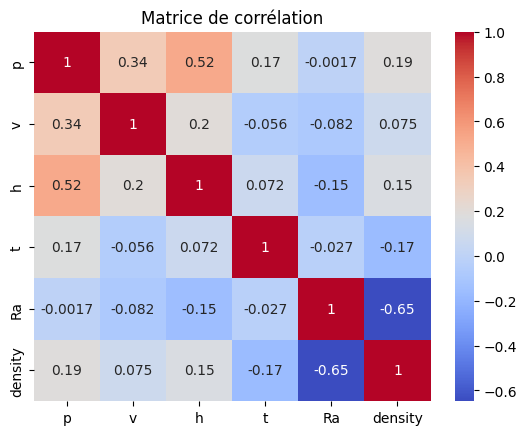

In [5]:

sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()


In [6]:
X=data[['p','v','h', 't']]
y=data[['Ra','density']]

In [7]:


Ra = y['Ra'].values.flatten()
density = y['density'].values.flatten()


scaler_X = RobustScaler()
X_scaled = scaler_X.fit_transform(X)


Ra_shifted = Ra + 1e-5  
Ra_boxcox, lambda_ra = boxcox(Ra_shifted)
scaler_Ra = RobustScaler()
Ra_scaled = scaler_Ra.fit_transform(Ra_boxcox.reshape(-1, 1))


scaler_density = RobustScaler()
density_scaled = scaler_density.fit_transform(density.reshape(-1, 1))


y_scaled = np.hstack([Ra_scaled, density_scaled])


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42, shuffle=True)


In [8]:
def inverse_transform(pred_scaled, lambda_ra, scaler_ra, scaler_dens):
    ra_inv = scaler_ra.inverse_transform(pred_scaled[:, 0].reshape(-1, 1))
    ra_orig = np.exp(np.log(ra_inv * lambda_ra + 1) / lambda_ra) - 1e-5

    dens_inv = scaler_dens.inverse_transform(pred_scaled[:, 1].reshape(-1, 1))
    return ra_orig.flatten(), dens_inv.flatten()

def print_metrics(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"—— Résultats pour {name} ——")
    print(f"R²    : {r2:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"MAPE  : {mape:.2f}%")
    print()

In [9]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 5000),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10)
    }
    
    rf = MultiOutputRegressor(RandomForestRegressor(random_state=42, **params))
    score = cross_val_score(rf, X_train, y_train, cv=3, scoring="r2", n_jobs=-1)
    return score.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300)

best_rf = RandomForestRegressor(random_state=42, **study.best_params)
multi_rf = MultiOutputRegressor(best_rf).fit(X_train, y_train)


y_pred = multi_rf.predict(X_test)

y_pred_ra, y_pred_density = inverse_transform(y_pred, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)

print_metrics(y_true_ra, y_pred_ra, "Ra")
print_metrics(y_true_density, y_pred_density, "Density")



c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-06-26 13:08:57,505] A new study created in memory with name: no-name-8e64b47f-a325-4035-88d8-c853cfe02e6d
[I 2025-06-26 13:09:21,516] Trial 0 finished with value: 0.7685904064210862 and parameters: {'n_estimators': 4964, 'max_depth': 17, 'min_samples_split': 28, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.7685904064210862.
[I 2025-06-26 13:09:34,306] Trial 1 finished with value: 0.8262802521494558 and parameters: {'n_estimators': 2133, 'max_depth': 18, 'min_samples_split': 13, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.8262802521494558.
[I 2025-06-26 13:09:38,682] Trial 2 finished with value: 0.7932046013623196 and parameters: {'n_estimators': 391, 'max_depth': 30, 'min_sampl

—— Résultats pour Ra ——
R²    : 0.9429
MAE   : 0.4624
RMSE  : 0.8995
MAPE  : 6.74%

—— Résultats pour Density ——
R²    : 0.9592
MAE   : 0.3527
RMSE  : 0.7674
MAPE  : 0.37%



In [10]:
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV


param_grid = {
    "estimator__C": [1, 10,100],
    "estimator__epsilon": [ 0.01, 0.1, 0.5, 1.0],
    "estimator__kernel": ['rbf', 'sigmoid','poly'],
    "estimator__degree": [2, 3, 4],
    "estimator__gamma": ['scale', 'auto']
}


base_svr = SVR()
multi_svr = MultiOutputRegressor(base_svr)


grid_search = GridSearchCV(
    multi_svr,
    param_grid,
    cv=3,
    scoring='r2',
    verbose=0,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_model_svr = grid_search.best_estimator_
y_pred = best_model_svr.predict(X_test)

y_pred_ra, y_pred_density = inverse_transform(y_pred, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)

print_metrics(y_true_ra, y_pred_ra, "Ra")
print_metrics(y_true_density, y_pred_density, "Density")

print("\n🔍 Best hyperparameters found:")
print(grid_search.best_params_)


—— Résultats pour Ra ——
R²    : 0.8984
MAE   : 0.6072
RMSE  : 1.1994
MAPE  : 8.33%

—— Résultats pour Density ——
R²    : 0.9280
MAE   : 0.5746
RMSE  : 1.0202
MAPE  : 0.60%


🔍 Best hyperparameters found:
{'estimator__C': 100, 'estimator__degree': 2, 'estimator__epsilon': 0.1, 'estimator__gamma': 'auto', 'estimator__kernel': 'rbf'}


In [12]:
import optuna
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor



def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 5000, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
    }

    model = MultiOutputRegressor(XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return mean_squared_error(y_test, y_pred)


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=300) 

best_params = study.best_params
best_model_xgb = MultiOutputRegressor(XGBRegressor(**best_params, random_state=42, n_jobs=-1))
best_model_xgb.fit(X_train, y_train)
y_pred_scaled = best_model_xgb.predict(X_test)


y_pred_ra, y_pred_density = inverse_transform(y_pred_scaled, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)



print_metrics(y_true_ra, y_pred_ra, "Ra")
print_metrics(y_true_density, y_pred_density, "Density")

print("\n✅ Best XGBoost parameters:")
for k, v in best_params.items():
    print(f"{k}: {v}")


[I 2025-06-26 15:00:39,090] A new study created in memory with name: no-name-87fe891a-f03b-463b-8352-ca73ba90de09
[I 2025-06-26 15:00:40,907] Trial 0 finished with value: 0.19875472819745782 and parameters: {'n_estimators': 1100, 'max_depth': 7, 'learning_rate': 0.0016665887330880715, 'subsample': 0.7810629676129559, 'colsample_bytree': 0.6711661940167732, 'gamma': 2.321777435986869, 'reg_alpha': 0.7124003476029499, 'reg_lambda': 0.3672658172773139}. Best is trial 0 with value: 0.19875472819745782.
[I 2025-06-26 15:00:41,034] Trial 1 finished with value: 0.2760105988161622 and parameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.010238631637556391, 'subsample': 0.8689954162316598, 'colsample_bytree': 0.5839797096571282, 'gamma': 3.042025181522125, 'reg_alpha': 0.2556320033647336, 'reg_lambda': 0.08560056987030673}. Best is trial 0 with value: 0.19875472819745782.
[I 2025-06-26 15:00:41,202] Trial 2 finished with value: 0.1450729147169869 and parameters: {'n_estimators':

—— Résultats pour Ra ——
R²    : 0.8463
MAE   : 0.6495
RMSE  : 1.4755
MAPE  : 7.65%

—— Résultats pour Density ——
R²    : 0.9529
MAE   : 0.4814
RMSE  : 0.8249
MAPE  : 0.50%


✅ Best XGBoost parameters:
n_estimators: 3200
max_depth: 6
learning_rate: 0.00871017867310119
subsample: 0.7610765789270507
colsample_bytree: 0.8825716711847291
gamma: 0.0023383307940705624
reg_alpha: 0.4459404593036358
reg_lambda: 0.48086311097591206


In [13]:
import optuna
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor



def objective_catboost(trial):
    
    params = {
        'iterations': trial.suggest_int('iterations', 100, 5000, step=100),
        'depth': trial.suggest_int('depth', 4, 16),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'verbose': 0
    }

    model = MultiOutputRegressor(CatBoostRegressor(**params))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

   
    return mean_squared_error(y_test, y_pred)

# Étude Optuna
study_catboost = optuna.create_study(direction='minimize')
study_catboost.optimize(objective_catboost, n_trials=300)

# Résultats
print("\n✅ Best hyperparameters for CatBoost:")
for key, value in study_catboost.best_params.items():
    print(f"{key}: {value}")


best_params_cat = study_catboost.best_params
best_model_cat = MultiOutputRegressor(CatBoostRegressor(**best_params_cat))
best_model_cat.fit(X_train, y_train)
y_pred_cat = best_model_cat.predict(X_test)


y_pred_ra, y_pred_density = inverse_transform(y_pred_cat, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)

# Évaluation
print_metrics(y_true_ra, y_pred_ra, "Ra (CatBoost)")
print_metrics(y_true_density, y_pred_density, "Density (CatBoost)")


[I 2025-06-26 15:09:45,293] A new study created in memory with name: no-name-c75eedd8-356c-480f-834f-a0a4017ba4c1
[I 2025-06-26 15:10:02,353] Trial 0 finished with value: 0.032895162804458464 and parameters: {'iterations': 4100, 'depth': 8, 'learning_rate': 0.010681985318244436, 'l2_leaf_reg': 6.347597486360481, 'border_count': 143, 'random_strength': 1.7467795938795316, 'bagging_temperature': 0.6507748477524905}. Best is trial 0 with value: 0.032895162804458464.
[I 2025-06-26 15:10:08,191] Trial 1 finished with value: 0.040304448797885126 and parameters: {'iterations': 3400, 'depth': 5, 'learning_rate': 0.07740064116415701, 'l2_leaf_reg': 6.992110795952337, 'border_count': 242, 'random_strength': 5.816332447443958, 'bagging_temperature': 0.08679478843091015}. Best is trial 0 with value: 0.032895162804458464.
[I 2025-06-26 15:10:13,144] Trial 2 finished with value: 0.05211252980660907 and parameters: {'iterations': 3900, 'depth': 4, 'learning_rate': 0.022340925403228552, 'l2_leaf_reg':

KeyboardInterrupt: 

In [15]:
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor

# Paramètres optimisés
best_params_cat = {
    'iterations': 5000,
    'depth': 12,
    'learning_rate': 0.06984341509111998,
    'l2_leaf_reg': 8.50995164960627,
    'border_count': 127,
    'random_strength': 0.10162231032474112,
    'bagging_temperature': 0.986758511415557,
    'verbose': 0  
}

# Entraînement du modèle avec MultiOutputRegressor
best_model_cat = MultiOutputRegressor(CatBoostRegressor(**best_params_cat))
best_model_cat.fit(X_train, y_train)

# Prédiction
y_pred_cat = best_model_cat.predict(X_test)

# Inversion des transformations
y_pred_ra, y_pred_density = inverse_transform(y_pred_cat, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)

# Évaluation des performances
print_metrics(y_true_ra, y_pred_ra, "Ra (CatBoost)")
print_metrics(y_true_density, y_pred_density, "Density (CatBoost)")


—— Résultats pour Ra (CatBoost) ——
R²    : 0.9625
MAE   : 0.4191
RMSE  : 0.7286
MAPE  : 5.78%

—— Résultats pour Density (CatBoost) ——
R²    : 0.9676
MAE   : 0.3864
RMSE  : 0.6837
MAPE  : 0.41%



In [17]:
import optuna
import numpy as np
from sklearn.metrics import mean_squared_error
from pytorch_tabnet.tab_model import TabNetRegressor
import torch

def objective(trial):
    params = {
        'n_d': trial.suggest_categorical('n_d', [ 64, 128,256,512]),
        'n_a': trial.suggest_categorical('n_a', [ 64, 128,256,512]),
        'n_steps': trial.suggest_int('n_steps', 3, 12),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-7, 1e-3, log=True),
        'optimizer_fn': torch.optim.Adam,
        'optimizer_params': dict(lr=trial.suggest_float('lr', 1e-4, 1e-2, log=True)),
        'mask_type': trial.suggest_categorical('mask_type', ['sparsemax', 'entmax']),
        'scheduler_params': {"step_size": 50, "gamma": 0.9},
        'scheduler_fn': torch.optim.lr_scheduler.StepLR,
        'verbose': 0,
    }

    batch_size = trial.suggest_categorical('batch_size', [32,64,128])
    virtual_batch_size = max(batch_size // 2, 1)

    try:
        model = TabNetRegressor(**params, device_name='cpu')

        model.fit(
            X_train=X_train,
            y_train=y_train,
            eval_set=[(X_test, y_test)],
            eval_metric=['rmse'],
            patience=40,
            max_epochs=300,
            batch_size=batch_size,
            virtual_batch_size=virtual_batch_size,
            num_workers=0,
            drop_last=False
        )

        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        print(f"Trial {trial.number} - RMSE: {rmse:.4f}")
        return rmse

    except Exception as e:
        print(f"Trial {trial.number} failed with error: {e}")
        return float('inf')  

# Lancer l'optimisation
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)


[I 2025-06-26 16:52:15,104] A new study created in memory with name: no-name-3459d00d-8f30-4a0b-84f2-e5b0b811a5d7



Early stopping occurred at epoch 241 with best_epoch = 201 and best_val_0_rmse = 0.21435


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-06-26 16:59:55,799] Trial 0 finished with value: 0.21435362222296883 and parameters: {'n_d': 256, 'n_a': 64, 'n_steps': 8, 'gamma': 1.9723893588545616, 'lambda_sparse': 8.518352385973607e-05, 'lr': 0.0034788091834139956, 'mask_type': 'sparsemax', 'batch_size': 32}. Best is trial 0 with value: 0.21435362222296883.


Trial 0 - RMSE: 0.2144


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-06-26 17:01:10,689] Trial 1 finished with value: 0.1819747679441635 and parameters: {'n_d': 64, 'n_a': 64, 'n_steps': 4, 'gamma': 1.5824035602620254, 'lambda_sparse': 0.00048456464742776444, 'lr': 0.00014793374743038543, 'mask_type': 'entmax', 'batch_size': 128}. Best is trial 1 with value: 0.1819747679441635.


...

Trial 47 - RMSE: 0.2594

Early stopping occurred at epoch 154 with best_epoch = 114 and best_val_0_rmse = 0.34868


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-06-26 18:55:22,528] Trial 48 finished with value: 0.3486781161032325 and parameters: {'n_d': 512, 'n_a': 256, 'n_steps': 5, 'gamma': 1.8999939114581637, 'lambda_sparse': 1.315789666578184e-06, 'lr': 0.0010368067138402113, 'mask_type': 'sparsemax', 'batch_size': 64}. Best is trial 21 with value: 0.15529633903462012.


Trial 48 - RMSE: 0.3487

Early stopping occurred at epoch 164 with best_epoch = 124 and best_val_0_rmse = 0.30134


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2025-06-26 18:57:53,918] Trial 49 finished with value: 0.30134018838314 and parameters: {'n_d': 128, 'n_a': 512, 'n_steps': 8, 'gamma': 1.4334208011340377, 'lambda_sparse': 9.127529319841356e-07, 'lr': 0.0006094059009476068, 'mask_type': 'sparsemax', 'batch_size': 128}. Best is trial 21 with value: 0.15529633903462012.


Trial 49 - RMSE: 0.3013


In [20]:

from pytorch_tabnet.tab_model import TabNetRegressor

best_params = {
    'n_d': 64,
    'n_a': 64,
    'n_steps': 7,
    'gamma': 1.0645338636747115,
    'lambda_sparse': 3.17595868835942e-07,
    'mask_type': 'entmax',
    'optimizer_params': {'lr': 0.005592454658238096}
}


best_model = TabNetRegressor(**best_params, device_name='cuda')


best_model.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=['rmse'],
    patience=40,
    max_epochs=300,
    batch_size=64,
    virtual_batch_size=32,
    num_workers=0,
    drop_last=False
)

y_pred_scaled = best_model.predict(X_test)


y_pred_ra, y_pred_density = inverse_transform(y_pred_scaled, lambda_ra, scaler_Ra, scaler_density)
y_true_ra, y_true_density = inverse_transform(y_test, lambda_ra, scaler_Ra, scaler_density)


print_metrics(y_true_ra, y_pred_ra, "Ra")
print_metrics(y_true_density, y_pred_density, "Density")


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 6.77424 | val_0_rmse: 3.68336 |  0:00:01s
epoch 1  | loss: 1.19189 | val_0_rmse: 1.60096 |  0:00:01s
epoch 2  | loss: 1.14341 | val_0_rmse: 1.2747  |  0:00:02s
epoch 3  | loss: 0.68582 | val_0_rmse: 0.92413 |  0:00:03s
epoch 4  | loss: 0.53316 | val_0_rmse: 1.78993 |  0:00:04s
epoch 5  | loss: 0.42746 | val_0_rmse: 0.93628 |  0:00:05s
epoch 6  | loss: 0.35978 | val_0_rmse: 0.64898 |  0:00:06s
epoch 7  | loss: 0.34056 | val_0_rmse: 0.74603 |  0:00:07s
epoch 8  | loss: 0.31362 | val_0_rmse: 0.73337 |  0:00:07s
epoch 9  | loss: 0.25002 | val_0_rmse: 0.56271 |  0:00:08s
epoch 10 | loss: 0.22467 | val_0_rmse: 0.46309 |  0:00:09s
epoch 11 | loss: 0.18882 | val_0_rmse: 0.50788 |  0:00:10s
epoch 12 | loss: 0.19609 | val_0_rmse: 0.36282 |  0:00:11s
epoch 13 | loss: 0.16131 | val_0_rmse: 0.36195 |  0:00:12s
epoch 14 | loss: 0.15131 | val_0_rmse: 0.40642 |  0:00:12s
epoch 15 | loss: 0.16146 | val_0_rmse: 0.40288 |  0:00:13s
epoch 16 | loss: 0.16982 | val_0_rmse: 0.40511 |  0:00:1

c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


—— Résultats pour Ra ——
R²    : 0.9686
MAE   : 0.4361
RMSE  : 0.6669
MAPE  : 5.49%

—— Résultats pour Density ——
R²    : 0.9685
MAE   : 0.4074
RMSE  : 0.6751
MAPE  : 0.43%



In [21]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, PReLU, Dropout
from tensorflow.keras.optimizers import Adam, AdamW, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner import RandomSearch

# 1. Définir le modèle à optimiser
def build_model(hp):
    model = Sequential()

    # Couche d'entrée
    model.add(Dense(
        units=hp.Int("units_input", min_value=64, max_value=512, step=64),
        input_dim=X_train.shape[1]
    ))
    if hp.Boolean("batchnorm_input"):
        model.add(BatchNormalization())
    model.add(PReLU())

    # Couches cachées
    for i in range(hp.Int("n_layers", 1, 4)):
        model.add(Dense(
            units=hp.Int(f"units_{i}", min_value=64, max_value=512, step=64)
        ))
        if hp.Boolean(f"batchnorm_{i}"):
            model.add(BatchNormalization())
        model.add(PReLU())
        if hp.Boolean(f"use_dropout_{i}"):
            model.add(Dropout(rate=hp.Float(f"dropout_{i}", 0.1, 0.5, step=0.1)))

    # Couche de sortie
    model.add(Dense(2, activation='linear'))

    # Optimiseur
    optimizer_name = hp.Choice('optimizer', ['Adam', 'AdamW', 'RMSprop'])
    lr = hp.Float('learning_rate', 1e-5, 1e-2, sampling='log')

    if optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=lr)
    elif optimizer_name == 'AdamW':
        optimizer = AdamW(learning_rate=lr)
    else:
        optimizer = RMSprop(learning_rate=lr)

    model.compile(optimizer=optimizer, loss='mse')
    return model


# 2. Créer le tuner
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=100,  
    executions_per_trial=1,
    directory='tuning_dir',
    project_name='mlp_slm'
)

# 3. EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True
)

# 4. Lancer la recherche
tuner.search(X_train, y_train,
             epochs=1000,
             validation_split=0.1,
             callbacks=[early_stop],
             batch_size=64,
             verbose=1)

# 5. Récupérer le meilleur modèle
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]
print("Meilleurs hyperparamètres trouvés :")
print(best_hps.values)



y_pred_scaled = best_model.predict(X_test)

Ra_pred_scaled = y_pred_scaled[:, 0].reshape(-1, 1)
density_pred_scaled = y_pred_scaled[:, 1].reshape(-1, 1)

Ra_pred_boxcox = scaler_Ra.inverse_transform(Ra_pred_scaled)
Ra_pred = inv_boxcox(Ra_pred_boxcox.flatten(), lambda_ra)

density_pred = scaler_density.inverse_transform(density_pred_scaled).flatten()

Ra_test_scaled = y_test[:, 0].reshape(-1, 1)
density_test_scaled = y_test[:, 1].reshape(-1, 1)

Ra_test_boxcox = scaler_Ra.inverse_transform(Ra_test_scaled)
Ra_test = inv_boxcox(Ra_test_boxcox.flatten(), lambda_ra)

density_test = scaler_density.inverse_transform(density_test_scaled).flatten()

# 8. Évaluation
print_metrics(Ra_test, Ra_pred, "Ra")
print_metrics(density_test, density_pred, "Density")


Trial 100 Complete [00h 02m 10s]
val_loss: 0.020418701693415642

Best val_loss So Far: 0.008247923105955124
Total elapsed time: 04h 53m 35s


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Meilleurs hyperparamètres trouvés :
{'units_input': 512, 'batchnorm_input': False, 'n_layers': 3, 'units_0': 512, 'batchnorm_0': True, 'use_dropout_0': True, 'optimizer': 'Adam', 'learning_rate': 0.0006581054818744375, 'dropout_0': 0.2, 'units_1': 128, 'batchnorm_1': True, 'use_dropout_1': False, 'units_2': 384, 'batchnorm_2': False, 'use_dropout_2': True, 'dropout_2': 0.2, 'dropout_1': 0.2, 'units_3': 256, 'batchnorm_3': False, 'use_dropout_3': False, 'dropout_3': 0.2}
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
—— Résultats pour Ra ——
R²    : 0.9864
MAE   : 0.2618
RMSE  : 0.4388
MAPE  : 3.77%

—— Résultats pour Density ——
R²    : 0.9850
MAE   : 0.2461
RMSE  : 0.4660
MAPE  : 0.25%



In [ ]:
best_model.save("best_RN_Ra_dens_model.h5") 
